# Técnicas de Aprendizaje Automático 2026
## Prueba de progreso: Análisis de tráfico mediante clustering
### Sara Hidalgo Salas

En esta práctica se realizará un análisis de datos de tráfico con el objetivo de identificar patrones de comportamiento mediante técnicas de aprendizaje no supervisado, concretamente clustering.

Para ello se utilizarán tres conjuntos de datos:

- **Datos de velocidad**: contienen información sobre la velocidad de los vehículos en diferentes tramos y franjas horarias.
- **Datos de volumen**: incluyen el número de vehículos que circulan por cada carril en distintos momentos.
- **Datos de estaciones**: proporcionan información geográfica y descriptiva de los puntos de medida.

A partir de estos datos se llevará a cabo:

1. Carga y exploración inicial de los datasets.
2. Limpieza y preprocesamiento de los datos.
3. Integración de la información en un único dataset.
4. Aplicación de técnicas de clustering.
5. Análisis e interpretación de los resultados obtenidos.

## **Carga de datos**

In [2]:
import pandas as pd

# cargamos los conjuntos de datos, lls datos estan separados por ; y y hacemos el encoding necesario para leer caracteres especiales
vel = pd.read_csv("20250915_datosvelocidad.csv", sep=";", encoding="ISO-8859-1")
vol = pd.read_csv("20250915_datosvolumen.csv", sep=";", encoding="ISO-8859-1")
est = pd.read_csv("estaciones.csv", sep=";", encoding="ISO-8859-1")

En esta sección se cargan los tres conjuntos de datos necesarios para el análisis utilizando la librería pandas.

Los archivos están separados por punto y coma (`;`) y utilizan una codificación específica (`ISO-8859-1`), por lo que es necesario indicarlo al leerlos.

In [3]:
print("Velocidad")
vel.head()

Velocidad


,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales,Unnamed: 13
0,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Lento N-I BAZKARDO,0,15,46,2,"92,94",32,31,63,NaN
1,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Central N-I BAZKARDO,0,0,4,0,100,2,2,4,NaN
2,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Lento SAN SEBASTIÁN,0,3,12,2,"98,53",15,2,17,NaN
3,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Central SAN SEBASTIÁN,0,3,18,1,"97,05",19,3,22,NaN
4,2025-09-15,01:00:00 - 01:30:00,GI-2132,"[GI-2132] 9101-ETD LASARTE-ORIA-ASTIGARRAGA, G...",Central LASARTE-ORIA,0,3,0,0,65,3,0,3,NaN


In [4]:
print("Volumen")
vol.head()

Volumen


,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,3,15/09/2025,01:00,37,8,40,3,4,0,45,3,53,2,1,0
1,3,15/09/2025,02:00,18,5,24,5,2,0,16,9,39,2,3,0
2,3,15/09/2025,03:00,8,4,16,4,0,0,14,19,20,5,0,1
3,3,15/09/2025,04:00,23,7,12,3,0,0,11,11,19,6,2,0
4,3,15/09/2025,05:00,44,15,44,4,11,0,29,16,27,3,1,0


In [5]:
print("Estaciones")
est.head()

Estaciones


,System,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-...",108,España,,,20,Gipuzkoa,,580428.65,4792191.27,-2.008765,43.278246,
GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, ...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896,
N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449,
N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142,
GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8,...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006,


Se muestran las primeras filas de cada dataset para comprobar:

- Que los datos se han cargado correctamente.
- Qué variables contiene cada dataset.
- Detectar posibles problemas iniciales (columnas vacías, formatos incorrectos, etc.).

# **Limpieza De Datos** 

## Limpieza del dataset de velocidad

Antes de realizar el análisis es necesario limpiar el dataset de velocidad para asegurar la calidad de los datos.

Se realizarán las siguientes operaciones:

- Eliminación de columnas vacías o innecesarias.
- Conversión de la velocidad media a formato numérico.
- Conversión de la fecha a formato datetime.
- Tratamiento de las horas para poder agrupar correctamente.

In [6]:
# hacmeos una copia del dataset original vel
vel_limpio = vel.copy()

# aqui eliminamos la columna vacia que no aporta nadita
vel_limpio = vel_limpio.drop(columns=["Unnamed: 13"])

# como la velocidad meida esta con coma la debemos cambiar por punto para poder luego convertir a numero
vel_limpio["Velocidad media (km/h)"] = vel_limpio["Velocidad media (km/h)"].str.replace(",", ".")

# ahroa convertimos la vel media a tipo float
vel_limpio["Velocidad media (km/h)"] = vel_limpio["Velocidad media (km/h)"].astype(float)

# convertimos la fecha que es texto a datetime
vel_limpio["Fecha"] = pd.to_datetime(vel_limpio["Fecha"])

vel_limpio.head()

,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales
0,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Lento N-I BAZKARDO,0,15,46,2,92.94,32,31,63
1,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Central N-I BAZKARDO,0,0,4,0,100.00,2,2,4
2,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Lento SAN SEBASTIÁN,0,3,12,2,98.53,15,2,17
3,2025-09-15,01:00:00 - 01:30:00,A-15,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",Central SAN SEBASTIÁN,0,3,18,1,97.05,19,3,22
4,2025-09-15,01:00:00 - 01:30:00,GI-2132,"[GI-2132] 9101-ETD LASARTE-ORIA-ASTIGARRAGA, G...",Central LASARTE-ORIA,0,3,0,0,65.00,3,0,3


Al hacer las transfromaciones anteriores podemos ver:
- Que la columna de velocidad ya es numerica
- Que fecha ya esta como datetime
- Y se elimino informacion que no aportaba nada

### Tratamiento de la variable hora

El formato original de la hora incluye intervalos (por ejemplo, "01:00:00 - 01:30:00"), por lo que se transforma para trabajar únicamente con la hora de inicio.

Además, se corrige un error en los datos donde se puede ver las horas con valor 24.

In [7]:
# se detectan las horas que empiezan por 24 
mask_24 = vel_limpio["Hora"].str.startswith("24")

# sumamos 1 dia cuadno se detecte que la hora es 24 
vel_limpio.loc[mask_24, "Fecha"] = vel_limpio.loc[mask_24, "Fecha"] + pd.Timedelta(days=1)

In [8]:
# nos quedamos con la hora de inicio
vel_limpio["Hora_inicio"] = vel_limpio["Hora"].str.split(" - ").str[0]

# extraemos la hora 
vel_limpio["Hora_inicio"] = vel_limpio["Hora_inicio"].str.split(":").str[0]

# onvertimos a tipo entero
vel_limpio["Hora_inicio"] = vel_limpio["Hora_inicio"].astype(int)

# aqui convertimos las horas para que queden de 0 a 23
vel_limpio["Hora_inicio"] = vel_limpio["Hora_inicio"] % 24

In [ ]:
vel_limpio[["Hora", "Hora_inicio"]].tail(20) # vemos que se ha hecho de forma correcto la transformacion

,Hora,Hora_inicio
75187,24:30:00 - 00:00:00,0
75188,24:30:00 - 00:00:00,0
75189,24:30:00 - 00:00:00,0
75190,24:30:00 - 00:00:00,0
75191,24:30:00 - 00:00:00,0


Se observa que las horas con valor "24:30:00" se han transformado correctamente a "0", lo que permite un tratamiento coherente del tiempo en formato horario (0-23).

Esto es fundamental para evitar errores en agrupaciones posteriores.

### Cálculo de la velocidad media ponderada

Dado que cada registro tiene un número distinto de vehículos, no es correcto calcular la media directamente.

Por ello, se calcula una velocidad media ponderada en función del número de vehículos.

In [10]:
# creamos velocidad ponderada y hacemos la velocidad x nº vehiculos
vel_limpio["velocidad_ponderada"] = (
    vel_limpio["Velocidad media (km/h)"] * vel_limpio["Vehículos totales"]
)

# agrupamos los datos por Fecha, Hora y ETD(que son las estaciones) y hacemos al suma de vehciulos y las velocidades
vel_hora = (
    vel_limpio
    .groupby(["Fecha", "Hora_inicio", "ETD"])
    .agg({
        "Vehículos totales": "sum",
        "velocidad_ponderada": "sum"
    })
    .reset_index()
)

# clculamos velocidad media REAL
vel_hora["Velocidad media (km/h)"] = (
    vel_hora["velocidad_ponderada"] /
    vel_hora["Vehículos totales"]
)

# se elimina la columna auxiliar ya que no es necesaria
vel_hora = vel_hora.drop(columns=["velocidad_ponderada"])

vel_hora.head()

,Fecha,Hora_inicio,ETD,Vehículos totales,Velocidad media (km/h)
0,2025-09-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",202,105.769455
1,2025-09-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,80...",83,56.685904
2,2025-09-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",224,103.816429
3,2025-09-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",235,98.831872
4,2025-09-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",222,94.575000


In [11]:
# extraemos el número de la estación desde ETD
vel_hora["Estacion"] = vel_hora["ETD"].str.extract(r'\] (\d+)-ETD')

# convertimos a entero
vel_hora["Estacion"] = vel_hora["Estacion"].astype(int)

vel_hora.head()

,Fecha,Hora_inicio,ETD,Vehículos totales,Velocidad media (km/h),Estacion
0,2025-09-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",202,105.769455,120
1,2025-09-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,80...",83,56.685904,134
2,2025-09-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",224,103.816429,259
3,2025-09-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",235,98.831872,303
4,2025-09-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",222,94.575000,315


## Limpieza del dataset de volumen

In [12]:
# copiamos el dataset
vol_limpio = vol.copy()

# se elimina los espacios en los nombres de las columnas
vol_limpio.columns = vol_limpio.columns.str.strip()

# se eliminan los espacios en todas las columnas tipo texto
for col in vol_limpio.select_dtypes(include={"object", "string"}):
    vol_limpio[col] = vol_limpio[col].str.strip()

# convertir fecha a datetime
vol_limpio["Fecha"] = pd.to_datetime(vol_limpio["Fecha"], dayfirst=True)

# corregimos el error de las 24 horas
mask_24 = vol_limpio["Hora"].astype(str).str.strip().str.startswith("24")

# cuando haya una fecha que tenga hora 24 se le suma 1 dia
vol_limpio.loc[mask_24, "Fecha"] = vol_limpio.loc[mask_24, "Fecha"] + pd.Timedelta(days=1)

# se extrae solo la hora
vol_limpio["Hora"] = vol_limpio["Hora"].str.split(":").str[0]

# convertimos de string a entero
vol_limpio["Hora"] = vol_limpio["Hora"].astype(int)

# aqui convertimos las horas para que queden de 0 a 23
vol_limpio["Hora"] = vol_limpio["Hora"] % 24

vol_limpio.head()

,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,3,2025-09-15,1,37,8,40,3,4,0,45,3,53,2,1,0
1,3,2025-09-15,2,18,5,24,5,2,0,16,9,39,2,3,0
2,3,2025-09-15,3,8,4,16,4,0,0,14,19,20,5,0,1
3,3,2025-09-15,4,23,7,12,3,0,0,11,11,19,6,2,0
4,3,2025-09-15,5,44,15,44,4,11,0,29,16,27,3,1,0


In [13]:
# seleccionamos las columnas de carriles
columnas_carriles = [col for col in vol_limpio.columns if "Carril" in col]

# convertimos carriles a números
vol_limpio[columnas_carriles] = vol_limpio[columnas_carriles].astype(int)

# se calcula y se crea el volumen total 
vol_limpio["Volumen_total"] = vol_limpio[columnas_carriles].sum(axis=1)# esto suma por filas

vol_limpio.head()

,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,Volumen_total
0,3,2025-09-15,1,37,8,40,3,4,0,45,3,53,2,1,0,196
1,3,2025-09-15,2,18,5,24,5,2,0,16,9,39,2,3,0,123
2,3,2025-09-15,3,8,4,16,4,0,0,14,19,20,5,0,1,91
3,3,2025-09-15,4,23,7,12,3,0,0,11,11,19,6,2,0,94
4,3,2025-09-15,5,44,15,44,4,11,0,29,16,27,3,1,0,194


## Limpieza del dataset de estaciones

In [14]:
# se corrige el desplazamiento de columnas, solo se lee los primeros 15 nombres de colummnas
est = pd.read_csv(
    "estaciones.csv",
    sep=";",
    encoding="latin-1",
    usecols=range(15)
)

# limpiamos los espacios de nombres de columnas
est.columns = est.columns.str.strip()

# se eliminan los espacios en todas las columnas tipo texto
for col in est.select_dtypes(include=["object", "string"]).columns:
    est[col] = est[col].str.strip()

est.head()

,System,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",108,España,,,20,Gipuzkoa,,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, G...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449
3,N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-I...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142
4,GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8, ...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006


In [15]:
# observamos que datos de la cokumna están vacios
for col in est.columns:
    if est[col].dtype in ["object", "string"]:
        vacios = (est[col] == "").sum()
        if vacios > 0:
            print(col, "->", vacios)

Municipality code -> 20
Municipality -> 20
Postal code -> 20


In [16]:
# hacmeos una copia del dataset original vel
est_limpio = est.copy()

# renombramos columnas
est_limpio = est_limpio.rename(columns={
    "System code": "ETD_texto",
    "ETD code": "Estacion"
})

est_limpio.head()

,System,Estacion,ETD_texto,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",108,España,,,20,Gipuzkoa,,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, G...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449
3,N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-I...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142
4,GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8, ...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006


In [17]:
# en las columnas que tienen datos vacios ponemos Desconocido
est_limpio["Municipality"] = est_limpio["Municipality"].replace("", "Desconocido")

est_limpio["Municipality code"] = est_limpio["Municipality code"].replace("", "Desconocido")

est_limpio["Postal code"] = est_limpio["Postal code"].replace("", "Desconocido")

est_limpio.head()

,System,Estacion,ETD_texto,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",108,España,Desconocido,Desconocido,20,Gipuzkoa,Desconocido,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, G...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.833330,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.10,-2.438889,43.192449
3,N-I,12,1,"[N-I] 12-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-I...",108,España,71,TOLOSA,20,Gipuzkoa,20400,575944.00,4778800.00,-2.065870,43.158142
4,GI-20,16,1,"[GI-20] 16-ETD USURBIL, AP-8-ERRENTERIA,AP-8, ...",108,España,69,DONOSTIA-SAN SEBASTIAN,20,Gipuzkoa,0,583607.00,4795202.00,-1.969142,43.305006


In [18]:
#Convertimos a tipo int las estaciones
est_limpio["Estacion"] = est_limpio["Estacion"].astype(int)
vel_hora["Estacion"] = vel_hora["Estacion"].astype(int)
vol_limpio["Estacion"] = vol_limpio["Estacion"].astype(int)

In [19]:
#Comprobamos que todo este en tipo int para que no de errores
print(est_limpio["Estacion"].dtype)
print(vel_hora["Estacion"].dtype)
print(vol_limpio["Estacion"].dtype)

int64
int64
int64


En esta fase se ha realizado:

- Carga de los tres datasets
- Limpieza de errores (columnas, formatos, valores)
- Transformación de variables clave (fecha, hora, velocidad)
- Creación de nuevas variables (velocidad ponderada, volumen total)
- Preparación para integración de datos

## **Integración de los datasets**
En esta sección se combinan los datasets de velocidad, volumen y estaciones para crear un único dataset que contenga toda la información necesaria para el análisis.

In [20]:
# usamos merge para poder unir tablas, entonces unimos la de velocidad y estaciones
# se une por la columna en comun estacion
vel_est = vel_hora.merge(
    est_limpio,
    on="Estacion",
    how="inner"
)

vel_est.head()

,Fecha,Hora_inicio,ETD,Vehículos totales,Velocidad media (km/h),Estacion,System,ETD_texto,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,2025-09-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",202,105.769455,120,A-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",108,España,72,URNIETA,20,Gipuzkoa,20130,581451.78,4789138.49,-1.996609,43.250651
1,2025-09-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,80...",83,56.685904,134,A-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,00...",108,España,Desconocido,Desconocido,20,Gipuzkoa,Desconocido,580942.00,4778272.00,-2.004769,43.152889
2,2025-09-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",224,103.816429,259,A-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,España,40,HERNANI,20,Gipuzkoa,20120,582630.00,4790090.00,-1.981954,43.259089
3,2025-09-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",235,98.831872,303,A-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,España,40,HERNANI,20,Gipuzkoa,20120,584443.42,4790895.66,-1.959492,43.266142
4,2025-09-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",222,94.575000,315,A-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",108,España,9,ANDOAIN,20,Gipuzkoa,20140,580078.96,4786639.97,-2.013880,43.228302


In [21]:
dataset_final = vel_est.merge(
    vol_limpio,
    left_on=["Estacion", "Fecha", "Hora_inicio"],
    right_on=["Estacion", "Fecha", "Hora"],
    how="inner"
)

dataset_final.head()

,Fecha,Hora_inicio,ETD,Vehículos totales,Velocidad media (km/h),Estacion,System,ETD_texto,Description,Country code,...,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,Volumen_total
0,2025-09-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",202,105.769455,120,A-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",108,...,0,0,0,58,62,10,1,0,0,202
1,2025-09-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,80...",83,56.685904,134,A-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,00...",108,...,0,0,0,30,9,0,0,0,0,83
2,2025-09-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",224,103.816429,259,A-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,...,71,11,1,19,2,52,11,1,1,224
3,2025-09-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",235,98.831872,303,A-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,...,4,0,0,71,11,4,0,0,0,235
4,2025-09-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",222,94.575000,315,A-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",108,...,6,0,0,32,5,40,7,0,0,222


In [22]:
# limpiamos columnas de hora
dataset_final = dataset_final.drop(columns=["Hora"])
dataset_final = dataset_final.rename(columns={"Hora_inicio": "Hora"})

dataset_final.head()

,Fecha,Hora,ETD,Vehículos totales,Velocidad media (km/h),Estacion,System,ETD_texto,Description,Country code,...,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,Volumen_total
0,2025-09-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",202,105.769455,120,A-15,1,"[A-15] 120-ETD ANDOAIN-SAN SEBASTIÁN, A-15 pk ...",108,...,0,0,0,58,62,10,1,0,0,202
1,2025-09-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,80...",83,56.685904,134,A-15,1,"[A-15] 134-ETD NAVARRA-ANDOAIN, A-15 pk 139,00...",108,...,0,0,0,30,9,0,0,0,0,83
2,2025-09-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",224,103.816429,259,A-15,1,"[A-15] 259-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,...,71,11,1,19,2,52,11,1,1,224
3,2025-09-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",235,98.831872,303,A-15,1,"[A-15] 303-ETD SAN SEBASTIÁN-ANDOAIN, A-15 pk ...",108,...,4,0,0,71,11,4,0,0,0,235
4,2025-09-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",222,94.575000,315,A-15,1,"[A-15] 315-ETD SAN SEBASTIÁN-N-I BAZKARDO, A-1...",108,...,6,0,0,32,5,40,7,0,0,222


## **Análisis exploratorio**

In [23]:
# sacamos una informacion general del dataset final
dataset_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 11925 entries, 0 to 11924
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Fecha                   11925 non-null  datetime64[us]
 1   Hora                    11925 non-null  int64         
 2   ETD                     11925 non-null  str           
 3   Vehículos totales       11925 non-null  int64         
 4   Velocidad media (km/h)  11925 non-null  float64       
 5   Estacion                11925 non-null  int64         
 6   System                  11925 non-null  str           
 7   ETD_texto               11925 non-null  int64         
 8   Description             11925 non-null  str           
 9   Country code            11925 non-null  int64         
 10  Country                 11925 non-null  str           
 11  Municipality code       11925 non-null  str           
 12  Municipality            11925 non-null  str           
 1

Se observa el número de filas y columnas del dataset, así como el tipo de cada variable.

Esto permite identificar:
- Variables numéricas y categóricas
- Posibles valores nulos

In [24]:
# buscamos valores vacios que sean texto
for col in dataset_final.columns:
    if dataset_final[col].dtype in ["object", "string"]:
        vacios = (dataset_final[col] == "").sum()
        if vacios > 0:
            print(col, "->", vacios)

In [25]:
# detectamos si hay valores nulos
dataset_final.isnull().sum()

Fecha                     0
Hora                      0
ETD                       0
Vehículos totales         0
Velocidad media (km/h)    0
Estacion                  0
System                    0
ETD_texto                 0
Description               0
Country code              0
Country                   0
Municipality code         0
Municipality              0
Territory code            0
Territory                 0
Postal code               0
GPSX                      0
GPSY                      0
X                         0
Y                         0
Carril 1 ligeros          0
Carril 1 pesados          0
Carril 2 ligeros          0
Carril 2 pesados          0
Carril 3 ligeros          0
Carril 3 pesados          0
Carril 4 ligeros          0
Carril 4 pesados          0
Carril 5 ligeros          0
Carril 5 pesados          0
Carril 6 ligeros          0
Carril 6 pesados          0
Volumen_total             0
dtype: int64

In [26]:
dataset_final.describe()# aqui calculamos las estadisticas de las variables 

,Fecha,Hora,Vehículos totales,Velocidad media (km/h),Estacion,ETD_texto,Country code,Territory code,GPSX,GPSY,...,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,Volumen_total
count,11925,11925.000000,11925.000000,11925.000000,11925.000000,11925.0,11925.0,11925.0,11925.000000,1.192500e+04,...,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000,11925.000000
mean,2025-09-18 01:23:33.735849,11.635304,973.149266,70.046999,769.546164,1.0,108.0,20.0,574842.061572,4.786013e+06,...,12.005954,32.619958,1.080755,235.606122,36.047379,149.078491,15.598826,32.139203,0.889895,958.768889
min,2025-09-15 00:00:00,0.000000,1.000000,25.000000,3.000000,1.0,108.0,20.0,537625.000000,4.757540e+06,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2025-09-16 00:00:00,6.000000,113.000000,56.447429,84.000000,1.0,108.0,20.0,559996.770000,4.774934e+06,...,0.000000,0.000000,0.000000,21.000000,2.000000,0.000000,0.000000,0.000000,0.000000,112.000000
50%,2025-09-18 00:00:00,12.000000,491.000000,70.581048,127.000000,1.0,108.0,20.0,579880.430000,4.791867e+06,...,0.000000,0.000000,0.000000,130.000000,11.000000,0.000000,0.000000,0.000000,0.000000,489.000000
75%,2025-09-20 00:00:00,18.000000,1365.000000,87.360278,253.000000,1.0,108.0,20.0,588445.960000,4.795501e+06,...,8.000000,0.000000,0.000000,389.000000,42.000000,158.000000,9.000000,0.000000,0.000000,1343.000000
max,2025-09-22 00:00:00,23.000000,7208.000000,109.680545,9259.000000,1.0,108.0,20.0,602668.420000,4.801978e+06,...,426.000000,1223.000000,68.000000,1829.000000,548.000000,1875.000000,335.000000,1546.000000,162.000000,7208.000000
std,NaN,6.903799,1184.169182,21.548415,2288.480349,0.0,0.0,0.0,18133.346211,1.215858e+04,...,33.030308,124.474629,4.880828,263.398284,62.889346,281.610019,40.338272,122.024941,4.360577,1164.450699


Se analizan las estadísticas descriptivas de las variables numéricas.

Esto permite observar:
- Rangos de valores
- Medias y desviaciones
- Posibles valores atípicos

Se aprecia que las variables presentan escalas muy diferentes, lo que indica que será necesario aplicar normalización antes del clustering.

In [27]:
import matplotlib.pyplot as plt# importmaos para hacer graficos 
import seaborn as sns

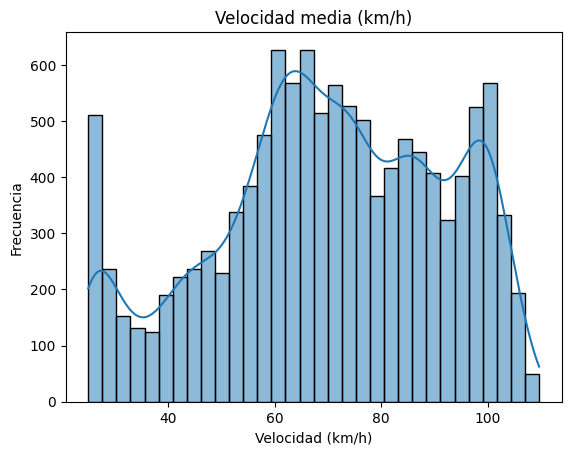

In [28]:
# creamos el histograma
sns.histplot(dataset_final["Velocidad media (km/h)"], kde=True)

# añadimos etiquetas
plt.title("Velocidad media (km/h)")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Frecuencia")
plt.show()

Observamos en la grafica que los datos de velocidad dependen si hay mas trafico o menos, por ejemplo, de 60 a 70 km/h podemos decir que hay tráfico moderado

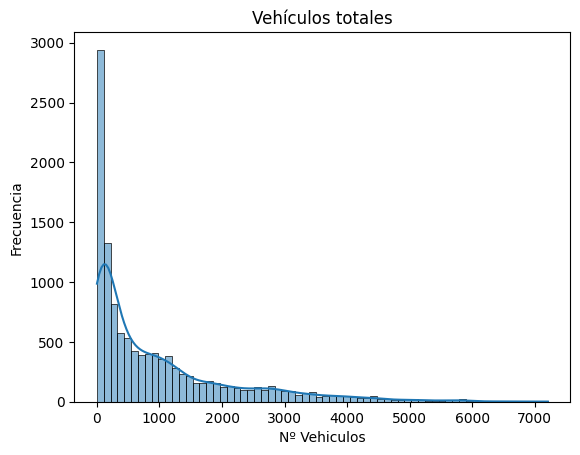

In [29]:
sns.histplot(dataset_final["Vehículos totales"], kde=True)
plt.title("Vehículos totales")
plt.xlabel("Nº Vehiculos")
plt.ylabel("Frecuencia")
plt.show()

Aqui observmaos la cantidad o frecuencia de veces que hay vehiculos, por ejemplo, de 0 a 500 es cuadno hay mas frecuencia por lo que se puede deber a que haya poco tráfico

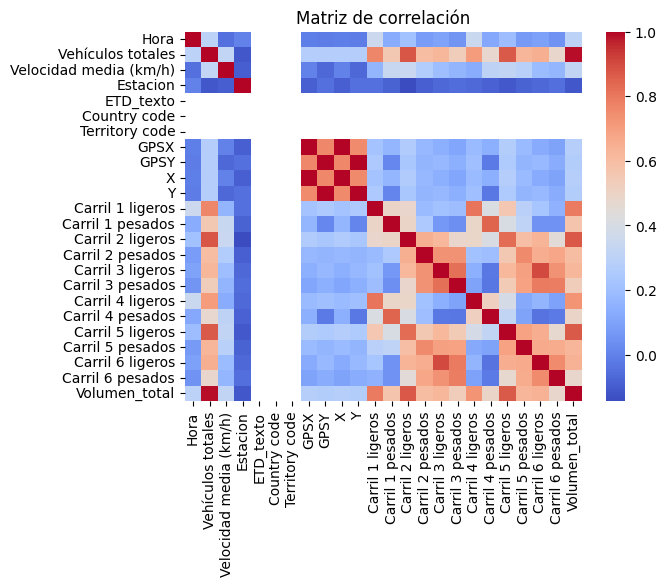

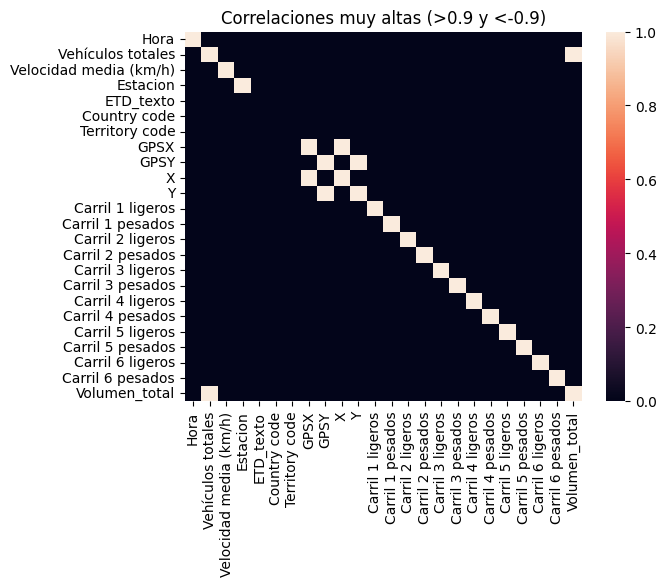

In [30]:
# seleccionamos solo columnas numéricas
df_num = dataset_final.select_dtypes(include=["int64", "float64"])

# calculamos las correlaciones entre 1 y -1, si dos variables se correlacionan mucho (se acercan a 1) es mejor eliminarlas
corr = df_num.corr()

# dibujamos el heatmap
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# Para ver correlaciones fuertes
sns.heatmap(corr.abs() > 0.95, annot=False)
plt.title("Correlaciones muy altas (>0.9 y <-0.9)")
plt.show()

In [31]:
# agrupamos por hora y hacmeos la media de vehiculos totales y la vel media
hora_trafico = dataset_final.groupby("Hora").agg({
    "Vehículos totales": "mean",
    "Velocidad media (km/h)": "mean"
}).reset_index()

hora_trafico.head()

,Hora,Vehículos totales,Velocidad media (km/h)
0,0,245.427146,70.882690
1,1,158.981443,71.242092
2,2,95.809224,71.748513
3,3,71.541935,72.203407
4,4,70.826087,72.716327


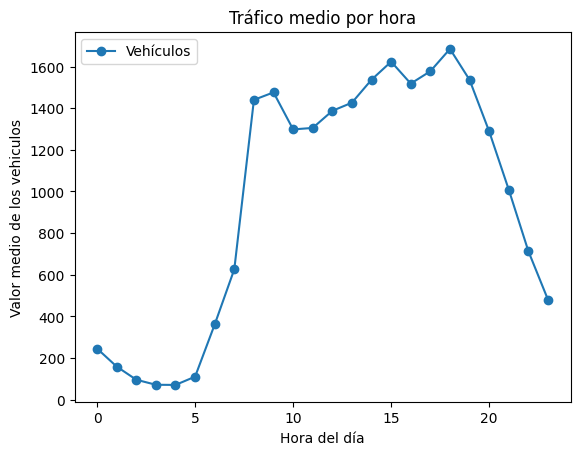

In [32]:
plt.plot(hora_trafico["Hora"], hora_trafico["Vehículos totales"], marker="o", label="Vehículos")

plt.xlabel("Hora del día")
plt.ylabel("Valor medio de los vehiculos")
plt.title("Tráfico medio por hora")
plt.legend()

plt.show()

Se puede observar que hay un menor numero de trafico en la madrugada y el pico mas alto de trafico es en las horas de por la tarde

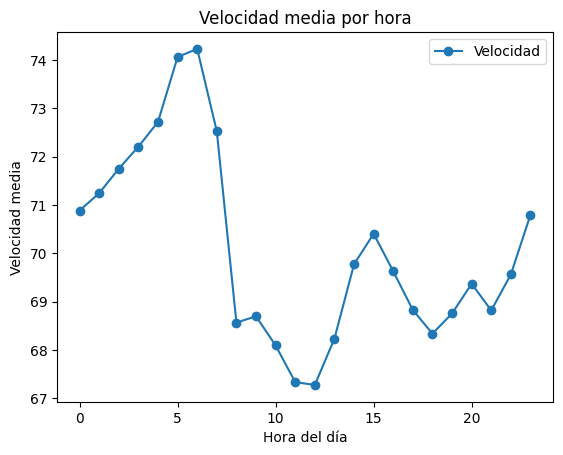

In [33]:
plt.plot(hora_trafico["Hora"], hora_trafico["Velocidad media (km/h)"], marker="o", label="Velocidad")

plt.xlabel("Hora del día")
plt.ylabel("Velocidad media")
plt.title("Velocidad media por hora")
plt.legend()

plt.show()

Vemos que a las 5 de la mañana al haber menos trafico los vehiculos van a mas velocidad

In [34]:
# agrupamos por estacion y hacemos la media de vehiculos totales y la vel media
estacion_trafico = dataset_final.groupby("Estacion").agg({
    "Vehículos totales": "mean",
    "Velocidad media (km/h)": "mean"
}).reset_index()# lo ponemos para que estacion no sea indice 

estacion_trafico.head()

,Estacion,Vehículos totales,Velocidad media (km/h)
0,3,1466.244048,81.785232
1,11,577.732143,55.201646
2,12,2057.142857,98.512617
3,16,1040.910180,74.687308
4,30,711.797619,83.007662


In [35]:
# Ordenamos las estaciones por vehiculos totales y de mayor a menor
estacion_trafico_ordenado = estacion_trafico.sort_values(by="Vehículos totales", ascending=False)

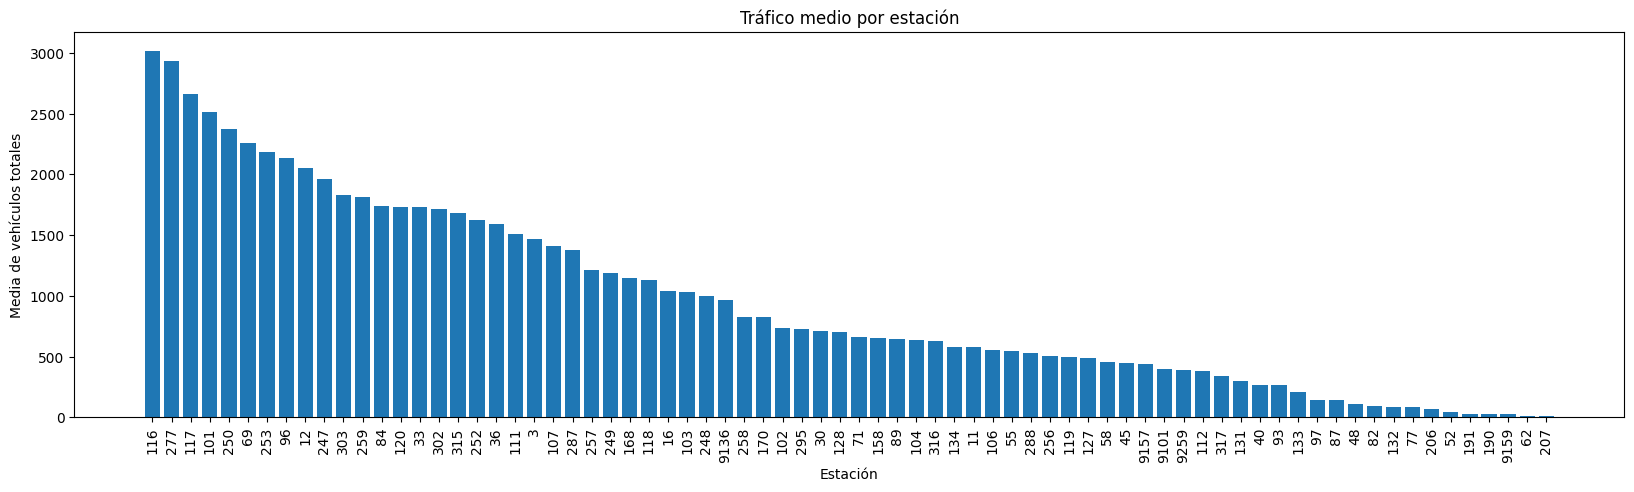

In [36]:
plt.figure(figsize=(20, 5))
        
        # Eje X
plt.bar(estacion_trafico_ordenado["Estacion"].astype(str), 
        # Eje Y
        estacion_trafico_ordenado["Vehículos totales"])

plt.title("Tráfico medio por estación")
plt.xlabel("Estación")
plt.ylabel("Media de vehículos totales")

plt.xticks(rotation=90)  # esto lo ponemos para girar las etiquetas y que se entiendan
plt.show()

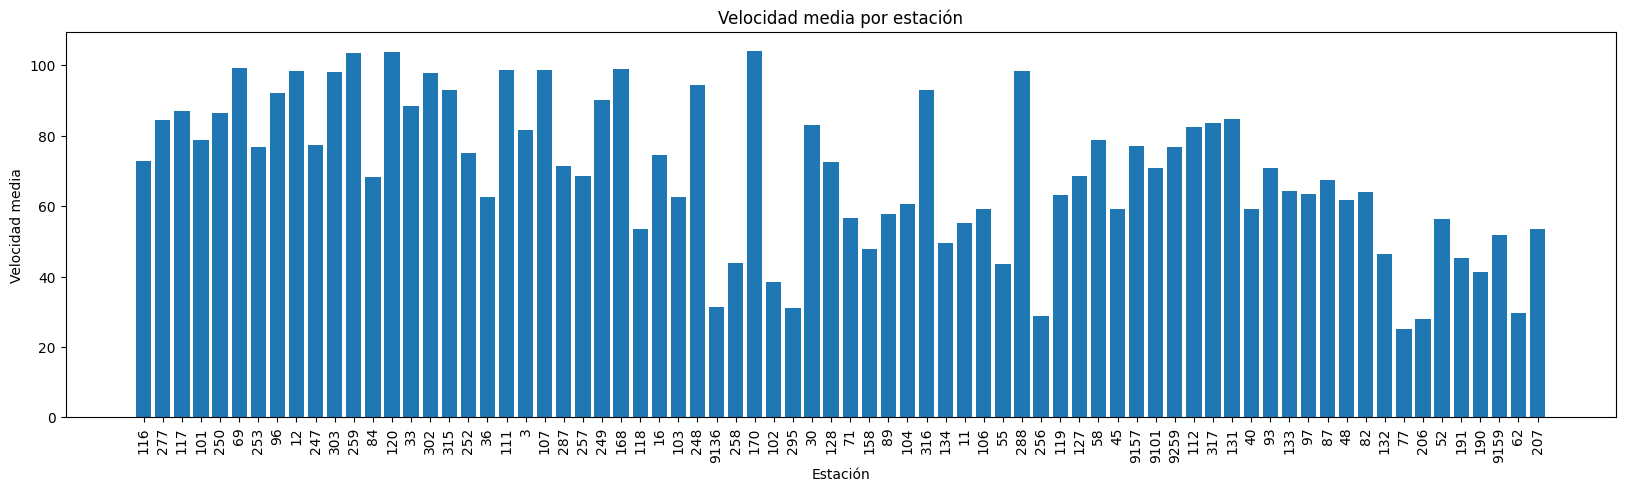

In [37]:
plt.figure(figsize=(20, 5))

plt.bar(estacion_trafico_ordenado["Estacion"].astype(str), 
        estacion_trafico_ordenado["Velocidad media (km/h)"])

plt.title("Velocidad media por estación")
plt.xlabel("Estación")
plt.ylabel("Velocidad media")

plt.xticks(rotation=90)
plt.show()

# Preprocesamiento

In [38]:
# creamos un nuevo dataset con las variables utiles
dataset_ml = dataset_final [[
    "Hora",
    "Vehículos totales",
    "Velocidad media (km/h)"
]]

dataset_ml.head()

,Hora,Vehículos totales,Velocidad media (km/h)
0,1,202,105.769455
1,1,83,56.685904
2,1,224,103.816429
3,1,235,98.831872
4,1,222,94.575000


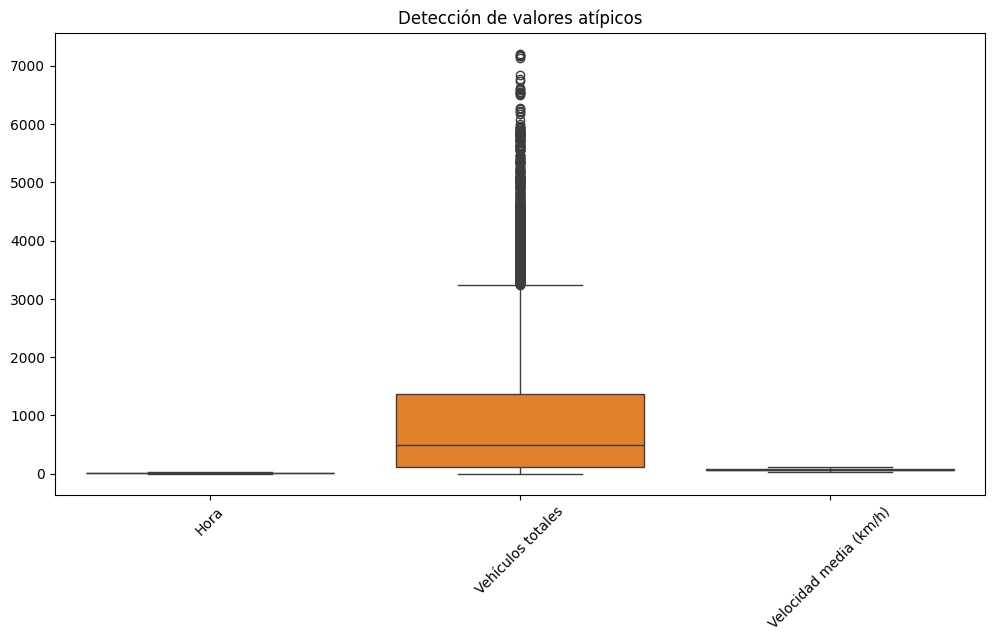

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(data=dataset_ml)
plt.xticks(rotation=45)
plt.title("Detección de valores atípicos")
plt.show()

Gracias a esto podemos detectar valores extremos, posibles errores y valores atípicos que pueden afectar al clustering

In [40]:
# aqui vamos a normalizar los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()# normaliza los datos

dataset_scaled = scaler.fit_transform(dataset_ml)# calculamos la media y desviacion y transforma los datos

dataset_scaled = pd.DataFrame(dataset_scaled, columns=dataset_ml.columns)# ahora convertimos a dataframe

dataset_scaled.head()

,Hora,Vehículos totales,Velocidad media (km/h)
0,-1.540565,-0.651243,1.657846
1,-1.540565,-0.751739,-0.620076
2,-1.540565,-0.632664,1.567208
3,-1.540565,-0.623374,1.335879
4,-1.540565,-0.634353,1.138322


# **Elección de algoritmo**

## K-Means

## Elección del algoritmo de clustering

Para este problema se han considerado varios algoritmos de clustering con el objetivo de encontrar patrones en el tráfico.

Se selecciona K-Means como algoritmo principal porque:
- Es eficiente con grandes volúmenes de datos
- Permite interpretar fácilmente los resultados mediante centroides
- Funciona bien cuando los datos están escalados
- Permite determinar el número de clusters mediante métodos como el codo o silhouette

Adicionalmente, se aplican otros algoritmos como DBSCAN, HDBSCAN y clustering jerárquico para comparar resultados y validar la estructura de los datos.

### Método del codo (ELBOW)
SIEMPRE va primero para elegir número de clusters


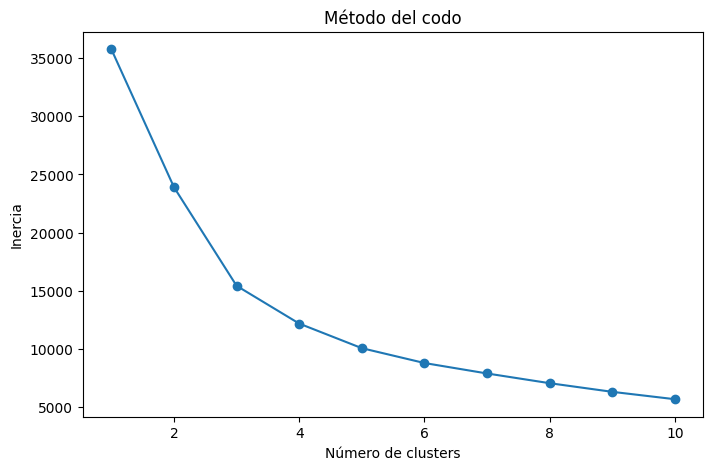

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# guarda el error de cada modelo
inertia = []

# valores de k de 1 a 10
K_range = range(1, 11)

# probamos valores de k de 1 a 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dataset_scaled)# entrena el modelo con los datos escalados
    inertia.append(kmeans.inertia_)# guarda el error

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

### Silhouette score

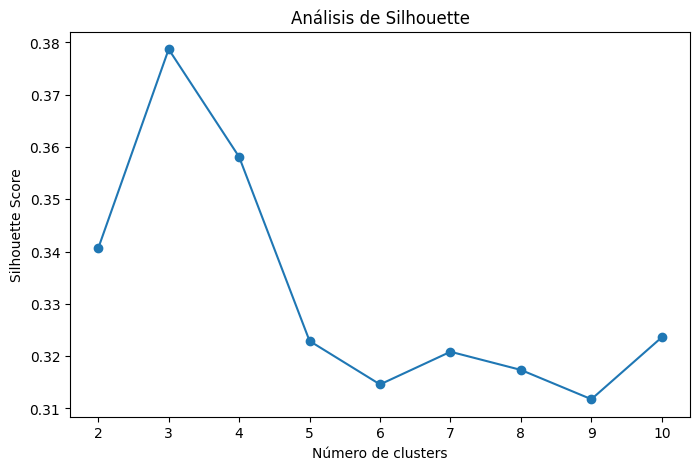

In [42]:
from sklearn.metrics import silhouette_score

# guardamos el puntuaje de cada k
silhouette_scores = []

K_range = range(2, 11)

# probmos de 2 a 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)# cremoa el modelo
    labels = kmeans.fit_predict(dataset_scaled)# entrenamos y asignamos el punto mas cercano al cluster
    
    score = silhouette_score(dataset_scaled, labels)# calcula el score
    silhouette_scores.append(score)# guarda el score

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Análisis de Silhouette")
plt.show()

Gracias a este analisis podemos elegir k, ya que cuanto mas cerca del 1 mejor, por lo que k seria 3

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)# creamos el modelo 
dataset_ml["cluster_kmeans"] = kmeans.fit_predict(dataset_scaled)# entrenamos y asignamos el punto mas cercano al cluster

# PCA
## Uso de PCA

Se aplica PCA para reducir la dimensionalidad del dataset y facilitar el clustering.

Esto permite:
- Reducir ruido en los datos
- Eliminar correlaciones entre variables
- Mejorar la separación entre clusters

Además, PCA facilita la visualización de los resultados en 2 dimensiones.

In [44]:
from sklearn.decomposition import PCA

In [45]:
#reducimos a 2 dimensiones
pca = PCA(n_components=2)
dataset_pca = pca.fit_transform(dataset_scaled)# se entrena y se transfroman los datos escalados

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.47277339 0.34883533]
Varianza acumulada: 0.8216087178808638


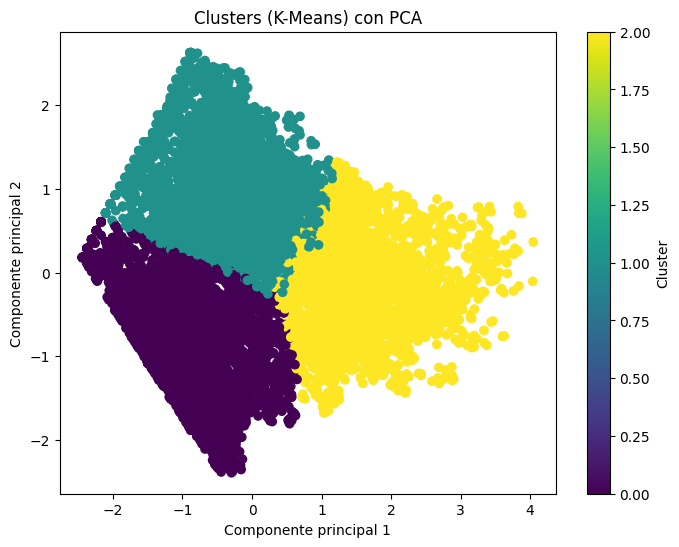

In [46]:
# visualización de clusters
plt.figure(figsize=(8,6))

# hacemos el grafico de puntos
plt.scatter(
    dataset_pca[:,0],
    dataset_pca[:,1],
    c=dataset_ml["cluster_kmeans"]
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters (K-Means) con PCA")
plt.colorbar(label="Cluster")
plt.show()



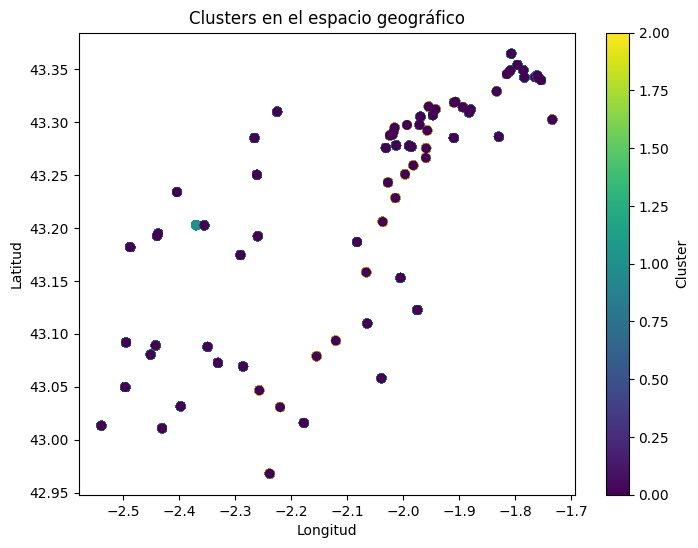

In [47]:
# Visualización geográfica
plt.figure(figsize=(8,6))
plt.scatter(
    dataset_final["X"],
    dataset_final["Y"],
    c=dataset_ml["cluster_kmeans"]
)

plt.title("Clusters en el espacio geográfico")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.colorbar(label="Cluster")
plt.show()

In [48]:
# contamos cuantos puntos hay en cada cluster
print(dataset_ml["cluster_kmeans"].value_counts())

cluster_kmeans
0    4479
1    4379
2    3067
Name: count, dtype: int64


In [49]:
# se agrupa por cluster y se hace la media, mediana y la desviacion estandar
cluster_summary = dataset_ml.groupby("cluster_kmeans").agg(["mean", "median", "std"])

cluster_summary

Hora                  Vehículos totales          \
                     mean median       std              mean  median   
cluster_kmeans                                                         
0                4.425541    4.0  3.141267        260.473543   140.0   
1               16.404659   17.0  4.520421        596.512674   477.0   
2               15.354744   15.0  4.417100       2551.684056  2415.0   

                            Velocidad media (km/h)                        
                        std                   mean     median        std  
cluster_kmeans                                                            
0                316.124390              73.307854  73.461978  18.056088  
1                516.106933              53.594356  55.910000  16.970083  
2               1220.675130              88.775646  91.638994  12.862327

In [50]:
dataset_ml = dataset_ml.drop(columns=["cluster_kmeans"])

## DBSCAN


In [51]:
from sklearn.cluster import DBSCAN

In [52]:
# creamos el modelo, se define el radio de vecinos y el numero de puntos para formar el cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)

dataset_ml["cluster_DBSCAN"] = dbscan.fit_predict(dataset_scaled)# entrenamos y asignamos el punto mas cercano al cluster

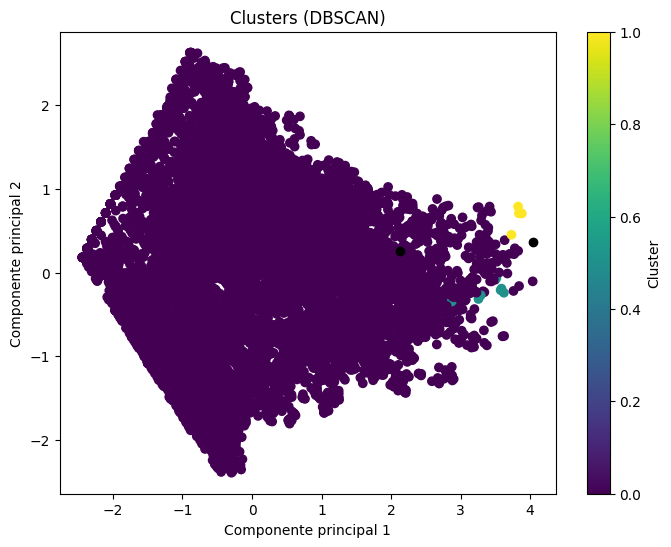

In [53]:
plt.figure(figsize=(8,6))

outliers_i = (dataset_ml["cluster_DBSCAN"] == -1)

plt.scatter(dataset_pca[~outliers_i, 0], dataset_pca[~outliers_i, 1], c = dataset_ml["cluster_DBSCAN"][~outliers_i])
plt.scatter(dataset_pca[outliers_i, 0], dataset_pca[outliers_i, 1], color="black")

plt.title("Clusters (DBSCAN)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.show()

In [54]:
# aqui contamos los cluster que hay
print(dataset_ml["cluster_DBSCAN"].value_counts())

cluster_DBSCAN
 0    11908
 1       10
 2        5
-1        2
Name: count, dtype: int64


In [55]:
# agrupoa por cluster y hace la media, mediana y desviacion 
cluster_summary_db = dataset_ml.groupby("cluster_DBSCAN").agg(["mean", "median", "std"])

cluster_summary_db

Hora                  Vehículos totales          \
                     mean median       std              mean  median   
cluster_DBSCAN                                                         
-1              12.000000   12.0  4.242641       6256.500000  6256.5   
 0              11.635371   12.0  6.906901        965.032919   490.0   
 1               8.500000    8.5  0.527046       6785.700000  6801.5   
 2              17.600000   18.0  0.894427       6564.600000  6555.0   

                            Velocidad media (km/h)                        
                        std                   mean     median        std  
cluster_DBSCAN                                                            
-1              1284.813021              62.502599  62.502599  12.171484  
 0              1165.220257              70.049497  70.593246  21.563146  
 1               404.282368              68.605123  68.850146   2.132190  
 2                39.195663              70.001165  70.230435   1.415141

### Conclusión

Se ha aplicado el algoritmo DBSCAN probando distintos valores de `eps` y `min_samples` con el objetivo de detectar agrupaciones basadas en densidad.

Los resultados muestran que:

- Para valores bajos de `eps`, se generan pequeños clusters poco significativos junto con algunos outliers.
- Para valores más altos de `eps`, prácticamente todos los puntos se agrupan en un único cluster.

En concreto:
- Con `eps=0.4` y `min_samples=10`, se obtiene un único cluster con algunos puntos considerados ruido.
- Con `eps=0.5` y `min_samples=10`, el comportamiento es similar.
- Reduciendo `min_samples` a 5, aparecen pequeños clusters adicionales, pero con muy pocos elementos, lo que indica que no representan patrones relevantes.

Esto sugiere que los datos no presentan una estructura de densidad bien definida, requisito fundamental para el correcto funcionamiento de DBSCAN.

Por tanto, se concluye que DBSCAN no es adecuado para este conjunto de datos, siendo preferible el uso de métodos como K-Means, que sí permiten identificar agrupaciones más interpretables.

In [56]:
dataset_ml = dataset_ml.drop(columns=["cluster_DBSCAN"])

## HDBSCAN

In [57]:
import hdbscan

# creamos el modelo y ponemos un cluster de 80 puntos 
hdb = hdbscan.HDBSCAN( min_cluster_size=80)

dataset_ml["cluster_HDBSCAN"] = hdb.fit_predict(dataset_scaled)# entrenamos y asignamos el punto mas cercano al cluster

In [58]:
# contamos cuantos puntos hay en cada cluster
print(dataset_ml["cluster_HDBSCAN"].value_counts())

cluster_HDBSCAN
-1    6760
 2    4889
 1     166
 0     110
Name: count, dtype: int64


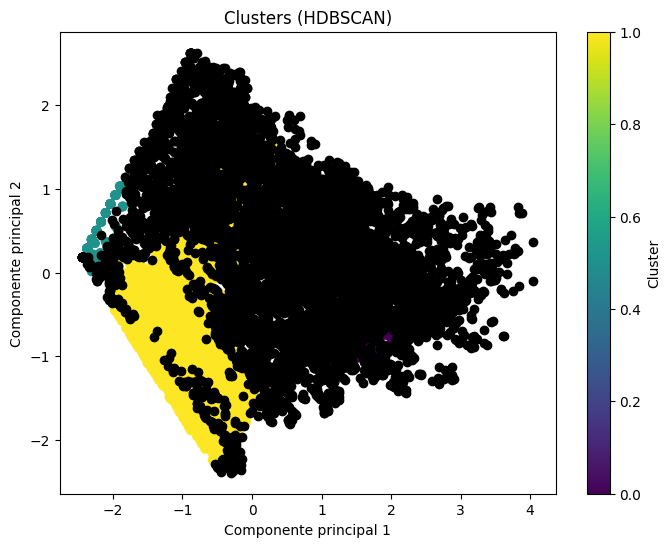

In [59]:
plt.figure(figsize=(8,6))

outliers_i = (dataset_ml["cluster_HDBSCAN"] == -1)

                    #Eje X                      #Eje y
plt.scatter(dataset_pca[~outliers_i, 0], dataset_pca[~outliers_i, 1], c = dataset_ml["cluster_HDBSCAN"][~outliers_i])

# dibujamos los puntos de ruido en negro
plt.scatter(dataset_pca[outliers_i, 0], dataset_pca[outliers_i, 1], color="black")

plt.title("Clusters (HDBSCAN)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.show()

In [60]:
# se agrupa por cluster y se hace la media, mediana y desviacion 
cluster_summary_hdb = dataset_ml.groupby("cluster_HDBSCAN").agg(["mean", "median", "std"])

cluster_summary_hdb

Hora                  Vehículos totales          \
                      mean median       std              mean  median   
cluster_HDBSCAN                                                         
-1               14.386243   15.0  5.472341       1524.064053  1170.0   
 0               12.154545   12.0  1.205388       2416.872727  2587.5   
 1                4.765060    5.0  3.022980         21.289157     4.0   
 2                8.053181    5.0  7.043473        211.237881   143.0   

                             Velocidad media (km/h)                        
                         std                   mean     median        std  
cluster_HDBSCAN                                                            
-1               1287.145424              70.468847  74.966445  24.695230  
 0                407.931324              99.522553  99.443543   1.976640  
 1                 30.374643              25.662413  25.000000   1.543705  
 2                219.168226              70.307552  66.870382  14.229917

### Conclusión

Se ha aplicado el algoritmo HDBSCAN probando distintos valores del parámetro `min_cluster_size` con el objetivo de detectar agrupaciones de densidad variable.

Los resultados obtenidos muestran comportamientos muy distintos según el valor elegido:

- Con `min_cluster_size = 20`, el algoritmo genera un gran número de clusters pequeños junto con una alta cantidad de ruido, lo que dificulta la interpretación de los resultados.
- Con `min_cluster_size = 50`, la mayoría de los datos se agrupan en un único cluster, acompañado de una pequeña cantidad de ruido y un cluster residual, indicando una falta de estructura clara.
- Con `min_cluster_size = 80`, se obtienen algunos clusters adicionales, pero con tamaños muy desbalanceados y una proporción elevada de puntos considerados ruido.

En conjunto, estos resultados indican que, aunque HDBSCAN permite capturar densidades variables mejor que DBSCAN, el conjunto de datos no presenta una estructura de densidad bien definida que permita obtener clusters interpretables mediante este tipo de algoritmos.

Por tanto, se concluye que los métodos basados en densidad no son los más adecuados para este problema, siendo preferible el uso de técnicas como K-Means, que permiten identificar agrupaciones más estables y fácilmente interpretables.

In [61]:
dataset_ml = dataset_ml.drop(columns=["cluster_HDBSCAN"])

## CLUSTERING JERÁRQUICO

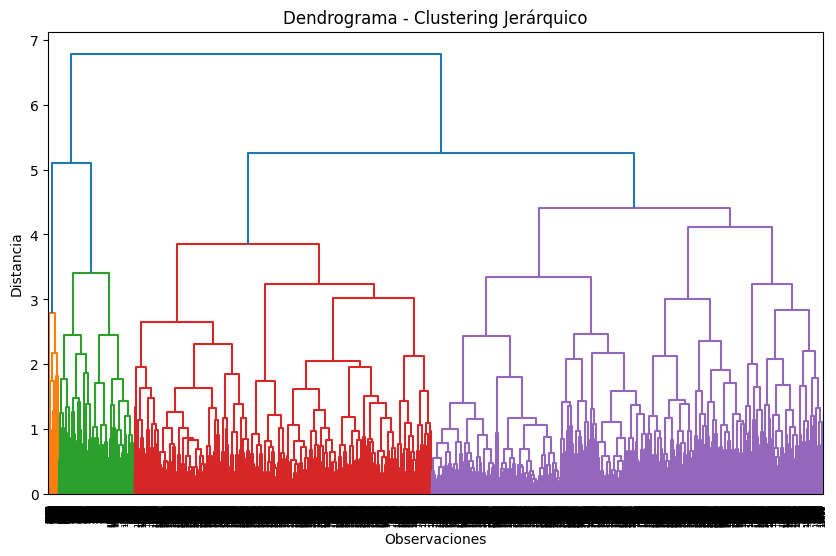

In [62]:
from scipy import cluster

# creamos el dendograma contruyendo la jerarquia de cluster, con el dataset normalizado y con el metood complete
linked = cluster.hierarchy.linkage(dataset_scaled, method='complete')# complete es hacer la distancia maxima

plt.figure(figsize=(10,6))
# dibujamos el dendrogama
cluster.hierarchy.dendrogram(linked)

plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

El dendrograma permite visualizar la estructura jerárquica de los datos y elegir el número de clusters mediante cortes en la distancia.

In [63]:
# creamos los clusters              
dataset_ml["cluster_Jerarquico"] = cluster.hierarchy.fcluster(linked, t=5, criterion='distance')
# lo que hacemos es convertir el dendrograma en clusters, usamos linked, el nivel de corte y la distance

In [64]:
# contmaos los cluster
dataset_ml["cluster_Jerarquico"].value_counts()

cluster_Jerarquico
4    6025
3    4569
2    1163
1     168
Name: count, dtype: int64

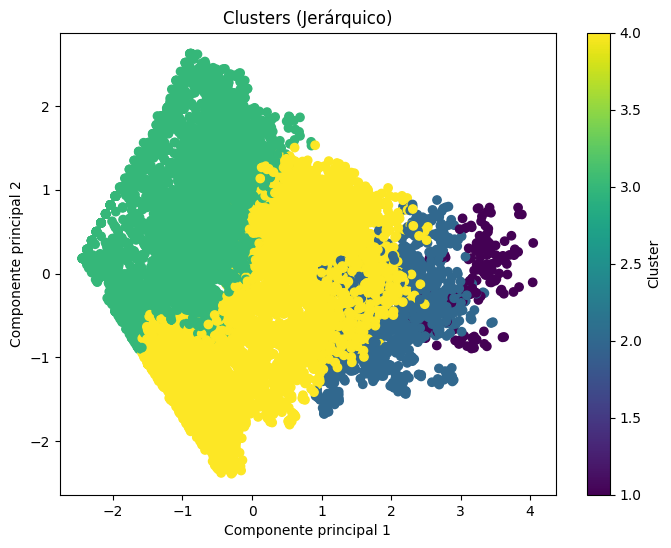

In [65]:
plt.figure(figsize=(8,6))
plt.scatter(
    dataset_pca[:,0],
    dataset_pca[:,1],
    c=dataset_ml["cluster_Jerarquico"]
)

plt.title("Clusters (Jerárquico)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.show()

In [66]:
cluster_summary_jer = dataset_ml.groupby("cluster_Jerarquico").agg(["mean", "median", "std"])

cluster_summary_jer

Hora                  Vehículos totales          \
                         mean median       std              mean  median   
cluster_Jerarquico                                                         
1                   14.000000   15.0  3.957862       5511.892857  5422.0   
2                   13.274291   13.0  3.551623       3228.829751  3235.0   
3                   12.592033   12.0  6.426152        404.118188   197.0   
4                   10.527469    9.0  7.587206        842.699087   595.0   

                               Velocidad media (km/h)                        
                           std                   mean     median        std  
cluster_Jerarquico                                                           
1                   588.726302              80.790032  84.566922   7.268656  
2                   767.447344              92.036561  95.546231   9.998500  
3                   461.537795              49.193010  51.666667  14.110151  
4                   819.432575              81.317238  81.161485  13.925795

### Conclusión

Se ha aplicado clustering jerárquico aglomerativo, utilizando un dendrograma previamente calculado y realizando distintos cortes en función del umbral de distancia (`t`).

Es importante destacar que, al utilizar `criterion='distance'`, el parámetro `t` no fija directamente el número de clusters, sino el nivel de corte en el dendrograma.

Se han probado distintos valores:

- Con `t = 4`, se obtienen 6 clusters, con tamaños relativamente equilibrados, aunque con cierta fragmentación.
- Con `t = 5`, se obtienen 4 clusters, más agrupados y fáciles de interpretar, aunque con cierta descompensación en tamaños.

En este caso, el corte con `t = 5` resulta más adecuado, ya que permite identificar una estructura global más clara sin generar una segmentación excesiva.

Estos resultados son coherentes con los obtenidos mediante K-Means, donde se identificaba una estructura de pocos clusters principales, lo que sugiere que los datos presentan agrupaciones más relacionadas con particiones del espacio que con densidades locales.

El clustering jerárquico permite visualizar la estructura de los datos, pero es menos eficiente para grandes volúmenes.

In [67]:
dataset_ml = dataset_ml.drop(columns=["cluster_Jerarquico"])

# Interpretación de resultados

## Interpretación de los clusters (K-Means)

Tras aplicar K-Means con 3 clusters, se han obtenido distintos perfiles de tráfico que permiten caracterizar el comportamiento del tráfico en función de la hora, el volumen y la velocidad.

Los clusters obtenidos permiten identificar claramente distintos patrones de tráfico:
- Tráfico fluido (poco volumen, alta velocidad)
- Tráfico congestionado (alto volumen, baja velocidad)
- Tráfico intenso pero eficiente (alto volumen y velocidad)
- Situaciones intermedias

Esto confirma que el clustering es útil para perfilar el comportamiento del tráfico por hora y zona, que era el objetivo de la práctica.

## Interpretación de DBSCAN

DBSCAN ha permitido identificar clusters de distinta densidad, así como detectar valores atípicos (ruido).

- El cluster -1 representa outliers, es decir, situaciones anómalas de tráfico.
- Los clusters principales muestran patrones similares a K-Means, pero con mayor flexibilidad en la forma.

Se observa que:

- Existen zonas con tráfico muy denso bien definidas
- Hay pequeños grupos de comportamiento distinto que K-Means no separa tan bien

Esto indica que el tráfico no sigue distribuciones completamente esféricas, lo que justifica el uso de algoritmos basados en densidad.

## Interpretación de HDBSCAN

HDBSCAN mejora a DBSCAN al detectar clusters de distinta densidad de forma automática.

Se observa:

- Mayor número de puntos clasificados como ruido
- Identificación de clusters más pequeños y específicos

Esto sugiere que el tráfico presenta estructuras complejas y heterogéneas, con zonas muy diferenciadas según localización y volumen.

## Interpretación del clustering jerárquico

El clustering jerárquico permite visualizar la estructura de los datos mediante el dendrograma.

Los clusters obtenidos muestran:

- Separación clara entre tráfico alto y bajo
- Subdivisiones dentro de cada grupo

Este método confirma los patrones observados anteriormente, aunque es menos práctico para grandes volúmenes de datos.

## Conclusión final

A partir del análisis realizado se concluye que:

Tras comparar los distintos algoritmos de clustering (K-Means, DBSCAN, HDBSCAN y clustering jerárquico), se concluye que K-Means es el más adecuado para este problema. 

Decimos esto ya que:
- Genera clusters claros
- No genera ruido excesivo
- Funciona bien con datos escalados
